# Day 4 — Risk Segmentation & Business Insight

**Project:** AI Model Failure Detection & Explainability System  
**Objective:** Transform churn prediction probabilities into business-friendly risk segments and extract actionable insights for telecom customer retention strategies.

This notebook focuses on converting raw model predictions into interpretable customer risk categories. Using the churn probability generated by the trained model, customers are segmented into Low, Medium, and High risk groups.

The analysis then investigates patterns within the high-risk customer segment by examining important telecom features such as customer tenure and monthly charges. These insights help identify the key factors associated with increased churn risk.

By translating model outputs into interpretable segments and behavioral insights, this analysis bridges the gap between machine learning predictions and practical business decision-making for telecom companies.

---

**Author:** Rishikesh Singh  
**Role:** Data Science Student  
**Project Stage:** Risk Segmentation & Business Insight (Day 4)  
**Tools:** Python, Pandas, Matplotlib, Seaborn

## Load Dataset and Trained Model

In this step we load the telecom churn dataset and the trained machine learning pipeline created earlier in the project.

The pipeline contains both preprocessing steps and the trained classification model.  
Loading the saved pipeline ensures that predictions generated in this notebook are consistent with previous analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

In [2]:
model = joblib.load("../models/baseline_pipeline.pkl")
print("Model loaded successfully")

Model loaded successfully


## Generate Predictions

The trained model pipeline is used to generate predictions for the telecom churn dataset.

Two outputs are produced:

- **Predicted churn class** (0 = No Churn, 1 = Churn)
- **Churn probability score**

The probability score represents the likelihood that a customer will churn and will later be used to create risk categories.

In [3]:
df = pd.read_csv("../data/dataset.csv")

df = df.drop(columns=['customerID'], errors='ignore')

X = df.drop(columns=['Churn'])
y = df['Churn']

In [4]:
from sklearn.preprocessing import LabelEncoder

cat_cols = X.select_dtypes(include=['object','string']).columns

le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col])

y = LabelEncoder().fit_transform(y)

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [7]:
results = X_test.copy()
results["Actual"] = y_test
results["Predicted"] = y_pred
results["Confidence"] = y_prob

results["Failure"] = results["Actual"] != results["Predicted"]

print("Failures:", results["Failure"].sum())

results.head()

Failures: 363


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual,Predicted,Confidence,Failure
437,1,0,1,1,72,1,2,1,2,2,...,2,2,1,1,114.05,6196,0,0,0.097583,False
2280,0,1,0,0,8,1,2,1,0,0,...,2,0,1,1,100.15,6340,0,1,0.904663,True
2235,0,0,1,1,41,1,2,0,2,2,...,0,1,1,1,78.35,2796,0,0,0.189133,False
4460,1,0,1,0,18,1,0,1,0,0,...,0,0,0,2,78.20,862,0,1,0.577528,True
3761,0,0,1,0,72,1,2,0,2,2,...,2,2,1,1,82.65,4855,0,0,0.063937,False


In [8]:
# Generate Risk Score
results["risk_score"] = y_prob

# Optional: create interpretable risk levels
results["risk_level"] = pd.cut(
    results["risk_score"],
    bins=[0, 0.3, 0.7, 1],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

results.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual,Predicted,Confidence,Failure,risk_score,risk_level
437,1,0,1,1,72,1,2,1,2,2,...,1,1,114.05,6196,0,0,0.097583,False,0.097583,Low Risk
2280,0,1,0,0,8,1,2,1,0,0,...,1,1,100.15,6340,0,1,0.904663,True,0.904663,High Risk
2235,0,0,1,1,41,1,2,0,2,2,...,1,1,78.35,2796,0,0,0.189133,False,0.189133,Low Risk
4460,1,0,1,0,18,1,0,1,0,0,...,0,2,78.20,862,0,1,0.577528,True,0.577528,Medium Risk
3761,0,0,1,0,72,1,2,0,2,2,...,1,1,82.65,4855,0,0,0.063937,False,0.063937,Low Risk


## Risk Score Distribution

This visualization shows how churn probabilities are distributed across customers.

The histogram helps identify whether most customers fall into low-risk groups or if there are significant numbers of high-risk customers that may require attention from the telecom company.

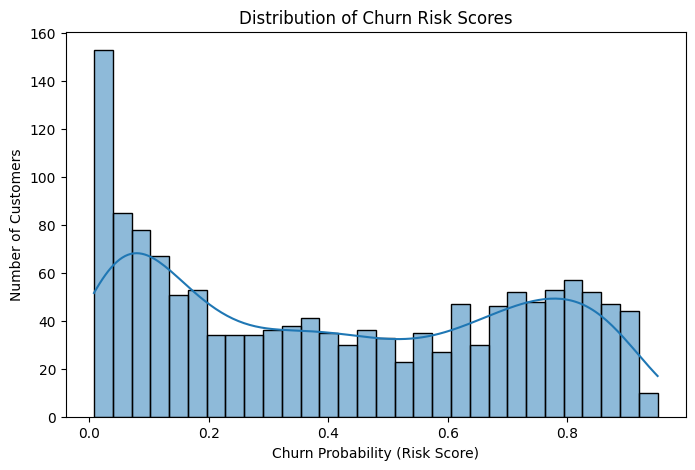

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(results["risk_score"], bins=30, kde=True)

plt.title("Distribution of Churn Risk Scores")
plt.xlabel("Churn Probability (Risk Score)")
plt.ylabel("Number of Customers")

plt.show()

## Customer Distribution by Risk Category

This step counts the number of customers in each churn risk category.

Understanding how customers are distributed across risk levels helps telecom companies estimate the scale of retention efforts required.

For example:
- High Risk customers may require targeted retention campaigns
- Medium Risk customers may benefit from loyalty offers
- Low Risk customers are relatively stable

In [10]:
# Count customers in each risk category
risk_counts = results["risk_level"].value_counts()

print(risk_counts)

risk_level
Low Risk       603
Medium Risk    443
High Risk      363
Name: count, dtype: int64


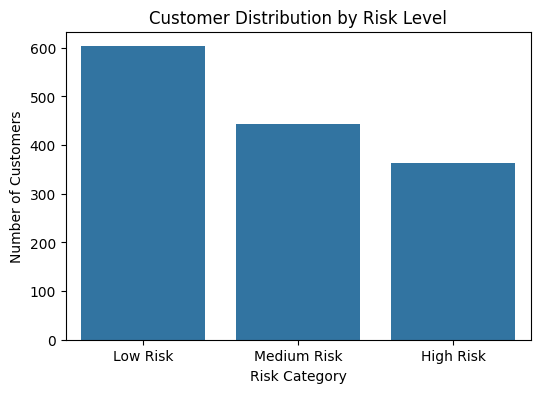

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x="risk_level", data=results)

plt.title("Customer Distribution by Risk Level")
plt.xlabel("Risk Category")
plt.ylabel("Number of Customers")

plt.show()

## High-Risk Customer Identification

In this step we isolate customers categorized as **High Risk** based on the churn probability generated by the model.

These customers have the highest likelihood of leaving the telecom service and therefore represent the most important group for retention strategies.

By analyzing this group separately, we can identify patterns that contribute to high churn risk.

In [12]:
# Filter high-risk customers
high_risk_customers = results[results["risk_level"] == "High Risk"]

# Number of high-risk customers
print("Number of High-Risk Customers:", len(high_risk_customers))

# Preview data
high_risk_customers.head()

Number of High-Risk Customers: 363


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual,Predicted,Confidence,Failure,risk_score,risk_level
2280,0,1,0,0,8,1,2,1,0,0,...,1,1,100.15,6340,0,1,0.904663,True,0.904663,High Risk
5748,0,0,0,0,21,1,2,1,0,2,...,1,1,99.85,1599,0,1,0.840823,True,0.840823,High Risk
3568,0,0,0,0,21,1,0,1,0,2,...,1,0,99.15,1558,0,1,0.710885,True,0.710885,High Risk
3524,0,1,0,0,11,1,2,1,0,0,...,1,1,84.80,6337,1,1,0.898600,False,0.898600,High Risk
2136,1,0,0,1,15,1,2,1,0,2,...,1,2,91.00,797,0,1,0.802245,True,0.802245,High Risk


## Tenure Pattern in High-Risk Customers

Customer tenure represents how long a customer has stayed with the telecom company.

Customers with shorter tenure are often more likely to churn because they have not yet developed strong loyalty to the service.

This analysis examines the tenure distribution among high-risk customers to determine whether new customers are more likely to fall into the high churn risk category.

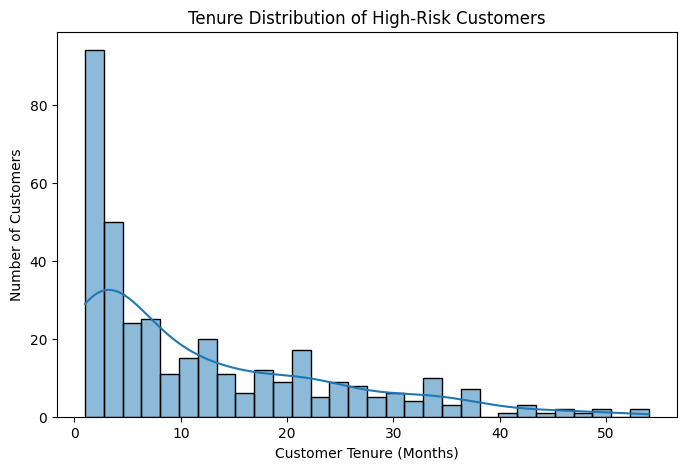

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(high_risk_customers["tenure"], bins=30, kde=True)

plt.title("Tenure Distribution of High-Risk Customers")
plt.xlabel("Customer Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

## Monthly Charges Pattern in High-Risk Customers

Monthly charges represent the amount a customer pays for telecom services each month.

Higher monthly costs can increase the likelihood of churn if customers perceive the service as expensive compared to alternatives.

This analysis examines whether customers with higher monthly charges are more likely to fall into the high-risk churn category.

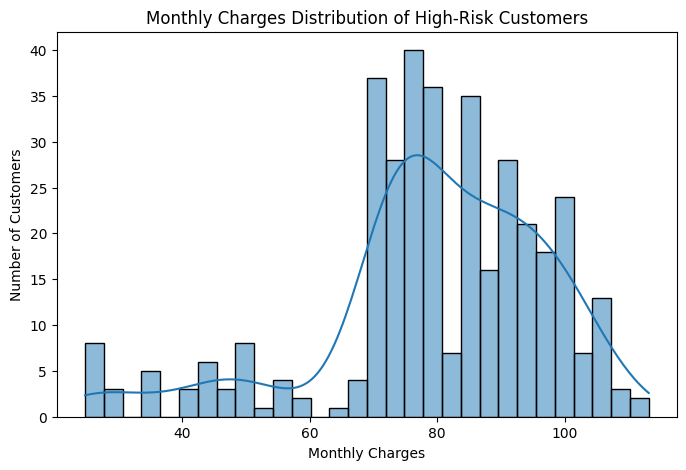

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(high_risk_customers["MonthlyCharges"], bins=30, kde=True)

plt.title("Monthly Charges Distribution of High-Risk Customers")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

## Business Insight Summary

The churn risk segmentation analysis provides valuable insights into customer behavior and potential churn drivers within the telecom dataset.

### Key Findings

**1. High-Risk Customer Segment**

The risk segmentation identified a group of customers with a high probability of churn. These customers represent the most important segment for telecom retention efforts.

**2. Short Tenure Customers Show Higher Churn Risk**

The tenure analysis indicates that many high-risk customers have relatively short tenure. This suggests that new customers are more likely to leave early in their subscription lifecycle before establishing strong service loyalty.

**3. Higher Monthly Charges Increase Churn Risk**

The monthly charges distribution shows that customers paying higher monthly fees are more likely to appear in the high-risk category. Pricing sensitivity may therefore contribute to increased churn probability.

### Business Implications

These insights allow telecom companies to design targeted retention strategies:

• Provide onboarding incentives to new customers to reduce early churn.  
• Offer loyalty rewards or discounts to customers with higher monthly bills.  
• Monitor high-risk customers and proactively offer retention campaigns before churn occurs.

### Project Outcome

By combining machine learning predictions with risk segmentation and behavioral analysis, this project transforms raw churn predictions into actionable business insights.

The system can help telecom companies:

- Identify customers likely to churn
- Understand the factors contributing to churn risk
- Design data-driven retention strategies

## Final Conclusion

This project demonstrates how machine learning models can be used not only to predict customer churn but also to provide meaningful insights for business decision-making.

Across the project stages, the workflow included:

• Data preprocessing and feature preparation  
• Model training and evaluation  
• Model failure analysis and explainability  
• Risk segmentation and churn pattern analysis  

The churn prediction model was able to estimate the probability of customer churn, which was then converted into risk categories to identify customers most likely to leave the service.

Further analysis of high-risk customers revealed important churn indicators such as shorter customer tenure and higher monthly charges.

By combining predictive modeling with business-oriented analysis, this system can support telecom companies in identifying vulnerable customers early and designing targeted retention strategies.

Overall, the project illustrates how machine learning can be integrated into business decision processes to improve customer retention and reduce churn.